In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [24]:
import numpy as np
import pandas as pd

def mad_based_outlier_removal(data, threshold=3.5):
    """
    Remove outliers using the Median Absolute Deviation (MAD) method.

    Parameters:
    -----------
    data : array-like or pd.Series
        The input data.
    threshold : float, default=3.5
        The modified z-score threshold. 
        (3.5 is a common choice)

    Returns:
    --------
    filtered_data : np.ndarray
        Data with outliers removed.
    """
    data = np.asarray(data)
    median = np.median(data)
    abs_dev = np.abs(data - median)
    mad = np.median(abs_dev)

    # Avoid division by zero
    if mad == 0:
        return data  

    # Modified Z-score
    modified_z_scores = 0.6745 * abs_dev / mad

    # Keep only non-outliers
    return data[modified_z_scores <= threshold]

In [2]:
colspecs = [
    (0, 17),    # 2FGL
    (18, 28),   # RAdeg
    (29, 39),   # DEdeg
    (40, 50),   # Name
    (51, 56),   # logF
    (57, 61),   # e_logF
    (62, 68),   # alpha
    (69, 75),   # e_alpha
    (76, 82),   # RMag
    (83, 87),   # e_RMag
    (88, 93),   # z
    (93, 94),   # u_z
    (95, 96),   # r_z
    (97, 102),  # zmin
    (103, 107), # z22.5
    (108, 112), # z22.9
    (113, 117), # zmax
    (118, 122), # Type
    (123, 126), # SED
    (127, 131), # Tel
    (132, 137), # MJD
]

colnames = [
    "2FGL", "RAdeg", "DEdeg", "Name", "logF", "e_logF", "alpha", "e_alpha",
    "RMag", "e_RMag", "z", "u_z", "r_z", "zmin", "z22.5", "z22.9", "zmax",
    "Type", "SED", "Tel", "MJD"
]

In [3]:
df = pd.read_fwf("apj458112t3_mrt.txt", skiprows = 57, colspecs=colspecs, names = colnames, na_values=['.'])

In [4]:
df

,2FGL,RAdeg,DEdeg,Name,logF,e_logF,alpha,e_alpha,RMag,e_RMag,...,u_z,r_z,zmin,z22.5,z22.9,zmax,Type,SED,Tel,MJD
0,2FGL J0000.9-0748,0.325017,-7.774111,J0001-0746,1.55,0.11,-1.399,0.003,NaN,NaN,...,NaN,NaN,NaN,0.33,0.50,1.84,BLL,IBL,P200,55064
1,2FGL J0007.8+4713,1.999862,47.202135,J0007+4712,1.32,0.14,-1.695,0.071,NaN,NaN,...,:,S,1.659,0.26,0.36,2.69,BLL,LBL,P200,55743
2,2FGL J0009.0+0632,2.267006,6.472664,J0009+0628,1.38,0.11,-1.410,0.007,NaN,NaN,...,NaN,NaN,NaN,0.58,0.76,1.65,BLL,LBL,WMKO,55040
3,2FGL J0009.1+5030,2.344750,50.508005,J0009+5030,1.51,0.11,-0.776,0.010,NaN,NaN,...,NaN,NaN,NaN,0.79,0.79,1.64,BLL,NaN,WMKO,55475
4,2FGL J0012.9-3954,3.249804,-39.907184,J0012-3954,1.01,0.11,-1.248,0.032,NaN,NaN,...,NaN,NaN,NaN,0.52,0.64,2.52,BLL,NaN,VLT,54362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,2FGL J2325.3+3957,351.324428,39.960088,J2325+3957,1.34,0.12,-1.468,0.020,NaN,NaN,...,NaN,NaN,1.052,0.64,0.76,1.85,BLL,LBL,WMKO,55357
368,2FGL J2329.2+3755,352.309382,37.904105,J2329+3754,1.73,0.11,-0.765,0.074,NaN,NaN,...,NaN,NaN,NaN,0.39,0.57,1.76,BLL,HBL,P200,55424
369,2FGL J2334.8+1431,353.724434,14.537353,J2334+1432,0.90,0.12,-1.466,0.068,NaN,NaN,...,NaN,NaN,NaN,0.41,0.45,2.66,BLL,NaN,HET,55390
370,2FGL J2352.0+1753,358.024445,17.820606,J2352+1749,1.46,0.11,-0.948,0.012,NaN,NaN,...,NaN,NaN,0.653,0.59,0.63,1.63,BLL,NaN,WMKO,55040


In [5]:
df_bll = df[df["Type"] == "BLL"]

In [48]:
len(df_bll)

353

In [37]:
bll_index = -df_bll["alpha"]
bll_index.size

353

In [44]:
bll_index_MAD_clipped = mad_based_outlier_removal(np.array(bll_index), threshold = 3.5)
print(f"The MAD clipped powerlaw indices range from {bll_index_MAD_clipped.min()} to {bll_index_MAD_clipped.max()}")

The MAD clipped powerlaw indices range from -0.291 to 2.25


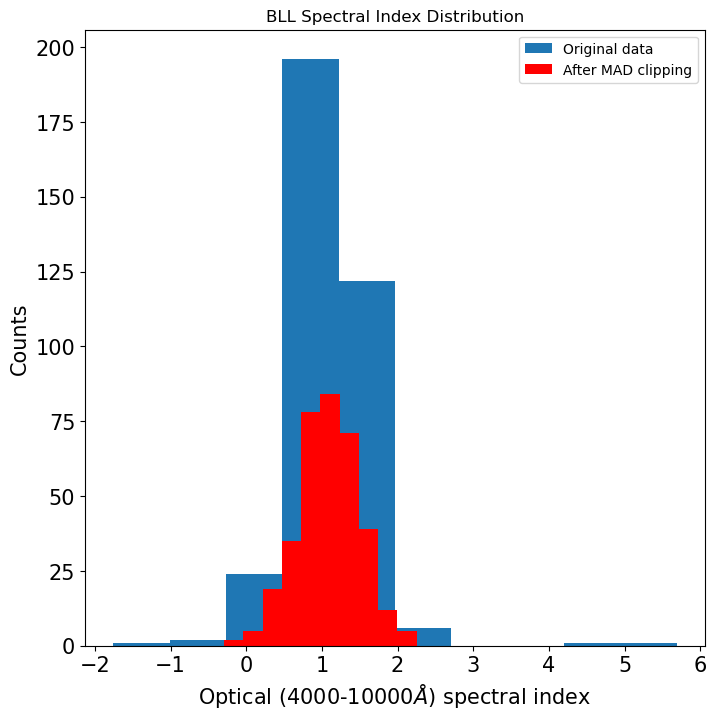

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8), sharex=False, nrows=1) ##sharex=True

ax.hist(bll_index, label = "Original data")
ax.hist(bll_index_MAD_clipped, color = "red",label = "After MAD clipping")
ax.set_xlabel(r"Optical (4000-10000$\AA$) spectral index", fontsize=15)
ax.set_ylabel("Counts", fontsize=15)

plt.tick_params(axis="both", which="both", labelleft=True, labelright=False, labelbottom=True, labeltop=False, labelsize = 15)
plt.title("BLL Spectral Index Distribution")


plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend();